    Value Category
0      75   Medium
1      82     High
2      65   Medium
3      70   Medium
4      80     High
5      60      Low
6      78     High
7      85     High
8      55      Low
9      50      Low
10     77     High
11     72   Medium


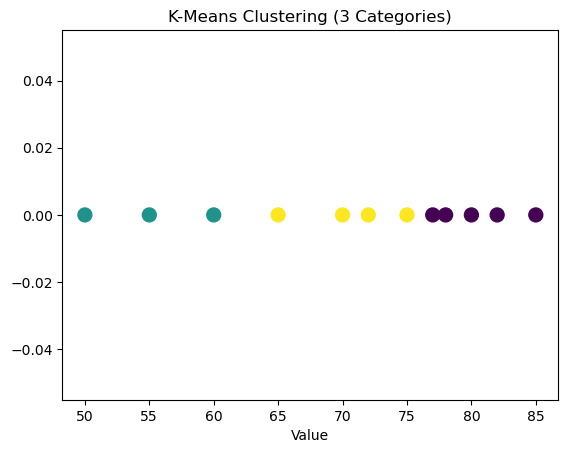

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Sample Data (Replace with your actual data)
data = {'Value': [75, 82, 65, 70, 80, 60, 78, 85, 55, 50, 77, 72]}
df = pd.DataFrame(data)

# Reshape into 2D array (required for K-Means)
X = df[['Value']].values

# Apply K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

# Assign meaningful category labels based on cluster means
cluster_means = df.groupby('Cluster')['Value'].mean().sort_values()
category_map = {cluster_means.index[0]: 'Low', cluster_means.index[1]: 'Medium', cluster_means.index[2]: 'High'}
df['Category'] = df['Cluster'].map(category_map)

# Print results
print(df[['Value', 'Category']])

# Visualize clusters
plt.scatter(df['Value'], [0] * len(df), c=df['Cluster'], cmap='viridis', s=100)
plt.xlabel("Value")
plt.title("K-Means Clustering (3 Categories)")
plt.show()